In [ ]:
# Importamos las librerías necesarias para el pre-procesado de los datos
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Dataset
data = pd.read_csv("financial_fraud_detection_dataset.csv", low_memory= False)

Se importan las librerías principales del proyecto (`numpy`, `matplotlib`, `pandas`) y se carga el dataset desde el CSV. El parámetro `low_memory=False` evita warnings al inferir tipos de datos en archivos grandes.

In [ ]:
data.shape

(5000000, 18)

El dataset original tiene **5.000.000 filas y 18 columnas**. Se trata de un dataset muy grande, lo que justifica la necesidad de reducirlo antes de modelar.

In [ ]:
data[data["is_fraud"]==1].shape

(179553, 18)

De los 5 millones de registros, **179.553 corresponden a fraude** (clase positiva), lo que representa aproximadamente el 3,6% del total. El dataset está claramente desbalanceado.

In [ ]:
# Filas NO fraude
no_fraud_idx = data[data['is_fraud'] == 0].index

# Seleccionar 3.5M aleatorias de esas
np.random.seed(42)
idx_to_drop = np.random.choice(no_fraud_idx, size=3_500_000, replace=False)

# Eliminar
data = data.drop(index=idx_to_drop).reset_index(drop=True)

Para reducir el volumen de datos manteniendo todos los casos de fraude, se eliminan aleatoriamente **3,5 millones de filas no fraudulentas** (con semilla fija para reproducibilidad). Esto deja un dataset manejable con mayor proporción de fraude.

In [ ]:
data[data['is_fraud']].shape

(179553, 18)

Tras la reducción, se confirma que los **179.553 casos de fraude se mantienen intactos** en el dataset reducido. La operación de submuestreo solo afectó a la clase mayoritaria.

In [ ]:
df = data.drop(columns = ["transaction_id", "sender_account","receiver_account","geo_anomaly_score", "ip_address", "device_hash" ])
df.head(20)

,timestamp,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,payment_channel
0,2023-09-24T08:09:02.700162,24.43,transfer,utilities,Toronto,mobile,False,NaN,NaN,0.79,13,ACH
1,2023-11-11T11:15:41.359248,59.51,payment,travel,Dubai,pos,False,NaN,NaN,-2.62,1,UPI
2,2023-08-04T00:35:03.745267,1237.07,deposit,travel,New York,web,False,NaN,NaN,1.64,3,card
3,2023-09-03T13:00:22.871266,1444.64,deposit,retail,Singapore,mobile,False,NaN,NaN,-1.15,5,card
4,2023-06-10T15:29:48.694371,1120.17,deposit,grocery,London,web,False,NaN,NaN,-0.28,4,wire_transfer
5,2023-05-20T16:03:55.763817,311.77,withdrawal,other,Toronto,atm,False,NaN,NaN,0.25,8,ACH
6,2023-03-08T15:56:46.580128,242.33,withdrawal,other,Toronto,atm,False,NaN,NaN,-0.43,14,UPI
7,2023-09-13T18:18:47.333219,149.59,deposit,entertainment,Sydney,mobile,False,NaN,NaN,1.18,13,card
8,2023-11-08T03:34:07.587904,671.66,deposit,restaurant,Dubai,atm,False,NaN,NaN,-0.57,17,card
9,2023-10-02T16:10:20.023696,66.38,payment,restaurant,New York,pos,False,NaN,NaN,0.41,6,wire_transfer


Hemos eliminado estas variables porque por la semántica del dato no tiene conexion con la variable objetivo a estudiar

In [ ]:
df.isna().sum()

,0
timestamp,0
amount,0
transaction_type,0
merchant_category,0
location,0
device_used,0
is_fraud,0
fraud_type,1320447
time_since_last_transaction,245460
spending_deviation_score,0


Se detectan valores nulos en varias columnas: `fraud_type` tiene casi todos sus valores como NaN (solo existe cuando hay fraude), y `time_since_last_transaction` también presenta muchos nulos. El resto de variables están completas.

In [ ]:
df['fraud_type'].value_counts()

,count
fraud_type,
card_not_present,179553


debido a la gran cantidad de NaN y que solo posee una clase,tipo de fraude se va a proceder a eliminarse.

In [ ]:
df = df.drop(columns=["fraud_type"])


Se elimina la columna `fraud_type` porque solo contiene un tipo de fraude para los casos positivos y es NaN para todos los negativos — aporta información redundante con `is_fraud` y no es útil como predictor.

In [ ]:
df['time_since_last_transaction'] = df['time_since_last_transaction'].fillna(0)
df.head()

,timestamp,amount,transaction_type,merchant_category,location,device_used,is_fraud,time_since_last_transaction,spending_deviation_score,velocity_score,payment_channel
0,2023-09-24T08:09:02.700162,24.43,transfer,utilities,Toronto,mobile,False,0.0,0.79,13,ACH
1,2023-11-11T11:15:41.359248,59.51,payment,travel,Dubai,pos,False,0.0,-2.62,1,UPI
2,2023-08-04T00:35:03.745267,1237.07,deposit,travel,New York,web,False,0.0,1.64,3,card
3,2023-09-03T13:00:22.871266,1444.64,deposit,retail,Singapore,mobile,False,0.0,-1.15,5,card
4,2023-06-10T15:29:48.694371,1120.17,deposit,grocery,London,web,False,0.0,-0.28,4,wire_transfer


Los NaN en `time_since_last_transaction` corresponden a transacciones sin historial previo. Se imputan con **0**, asumiendo que si no hay transacción anterior, el tiempo transcurrido es nulo.

In [ ]:
df.dtypes

,0
timestamp,object
amount,float64
transaction_type,object
merchant_category,object
location,object
device_used,object
is_fraud,bool
time_since_last_transaction,float64
spending_deviation_score,float64
velocity_score,int64


Vemos que la fecha la trata como objeto en vez de datetime por lo que se va a cambiar

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')

La columna `timestamp` se convierte de tipo `object` a `datetime` usando el parámetro `format='mixed'` para manejar formatos de fecha heterogéneos en el dataset.

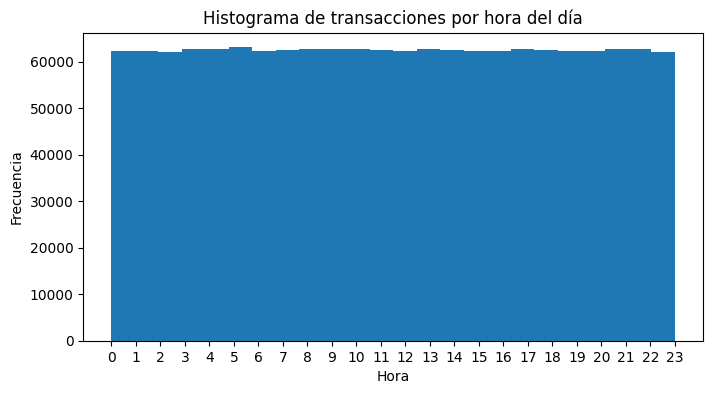

In [ ]:
df['hora'] = df['timestamp'].dt.hour

plt.figure(figsize=(8, 4))
plt.hist(df['hora'].dropna(), bins=24)
plt.title('Histograma de transacciones por hora del día')
plt.xlabel('Hora')
plt.ylabel('Frecuencia')
plt.xticks(range(0, 24))
plt.show()

Hemos pasado la variable timestamp a el formato datetime(ns) porque había algunas que contenían microsegundos, de esta manera se trata a todas de forma homogénea. Vemos que hay prácticamente el mismo numero de transacciones en cada hora del dia

In [ ]:
categoricas = df.select_dtypes(include=['object', 'category', 'bool']).columns

for col in categoricas:
    tabla = pd.DataFrame({
        'frecuencia': df[col].value_counts(dropna=False),
        'porcentaje': df[col].value_counts(normalize=True, dropna=False) * 100
    })

    print(f"\nTabla de frecuencias: {col}")
    display(tabla)


Tabla de frecuencias: transaction_type


,frecuencia,porcentaje
transaction_type,,
deposit,375768,25.051200
payment,375091,25.006067
transfer,374713,24.980867
withdrawal,374428,24.961867



Tabla de frecuencias: merchant_category


,frecuencia,porcentaje
merchant_category,,
retail,188095,12.539667
entertainment,187981,12.532067
other,187866,12.524400
travel,187652,12.510133
restaurant,187472,12.498133
grocery,187112,12.474133
online,187039,12.469267
utilities,186783,12.452200



Tabla de frecuencias: location


...

,frecuencia,porcentaje
device_used,,
mobile,375660,25.044000
atm,375096,25.006400
pos,374662,24.977467
web,374582,24.972133



Tabla de frecuencias: is_fraud


,frecuencia,porcentaje
is_fraud,,
False,1320447,88.0298
True,179553,11.9702



Tabla de frecuencias: payment_channel


,frecuencia,porcentaje
payment_channel,,
wire_transfer,376196,25.079733
ACH,375421,25.028067
UPI,374249,24.949933
card,374134,24.942267


Todas las clases menos is_fraud están balanceadas (tienen prácticamente el mismo número de observaciones por cada clase distinta). Isfraud está claramente desbalanceada (mas de 88% en False) como es habitual en bases de datos de detección de fraude

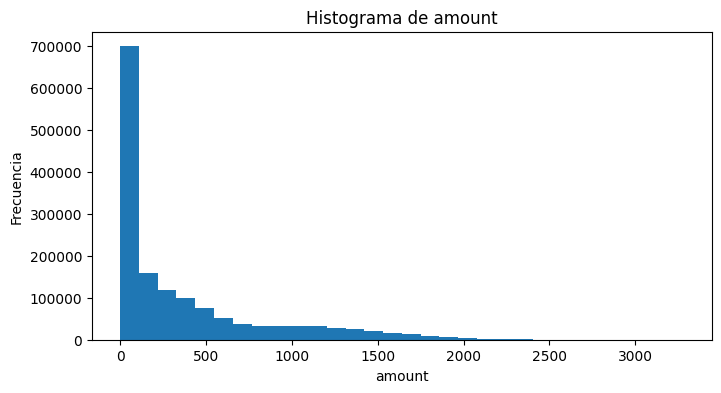

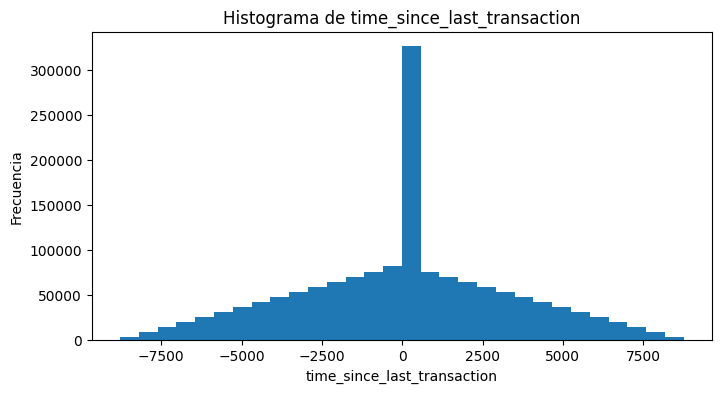

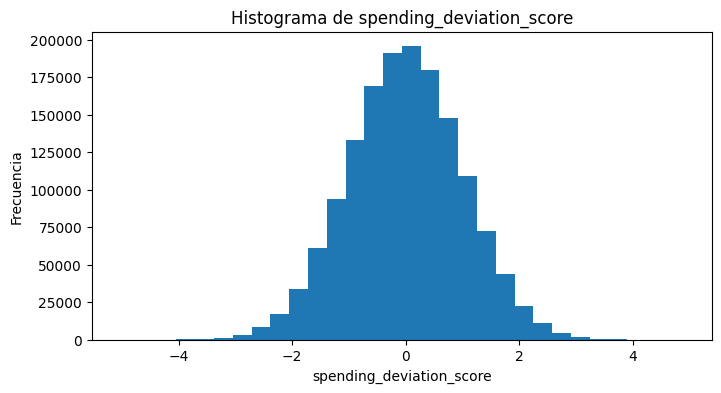

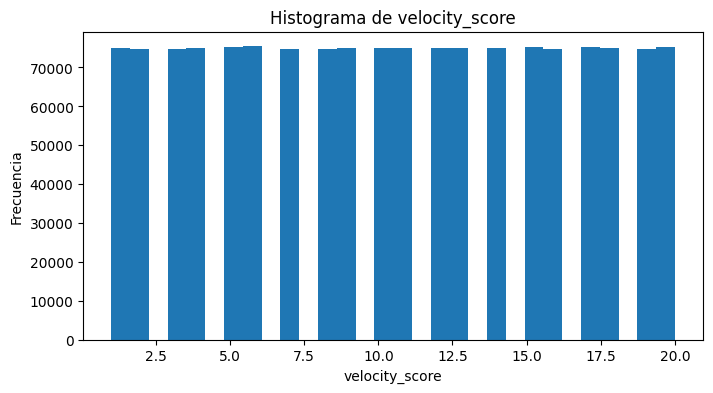

In [ ]:
numericas = df.select_dtypes(include=['int64', 'float64']).columns

for col in numericas:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f'Histograma de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

Amount: Presenta una gran cantidad de datos cercanos a 0, con forma exponencial negativa. se aplicará posteriormente una transformacion logaritmica a esta variable para reducir este sesgo

time_since_last_transaction: esta variable esta ya previamente normalizada puesto que tiene forma de distribucion gaussiana. El numero elevado de valores en 0 es porque al ser gaussiana la media,mediana y moda es 0, por lo que se sustituyeron por ese valor

Spending_deviation_score: Presenta una distribución aproximadamente normal, centrada en torno a 0, con valores tanto positivos como negativos. Esto indica que la variable mide desviaciones respecto al comportamiento habitual del usuario: valores cercanos a 0 representan un comportamiento típico, mientras que valores extremos (positivos o negativos) reflejan patrones de gasto inusuales. La forma de la distribución es coherente con este tipo de variable, por lo que no requiere transformaciones adicionales en una primera aproximación.

Velocity_score: Presenta una distribución aproximadamente uniforme en su rango de valores, sin una concentración clara en intervalos específicos. Esto indica que la variable ha sido generada o discretizada de forma homogénea, lo cual puede limitar su capacidad para capturar patrones reales de comportamiento. Al tratarse de una variable discreta relacionada con la frecuencia o rapidez de transacciones, su utilidad deberá evaluarse en combinación con otras variables, ya que por sí sola no muestra una estructura informativa evidente.

In [ ]:
df.describe()

,timestamp,amount,time_since_last_transaction,spending_deviation_score,velocity_score,hora
count,1500000,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06
mean,2023-07-03 04:00:22.235396608,3.596085e+02,2.863957e+00,-6.478200e-04,1.050160e+01,1.149796e+01
min,2023-01-01 00:12:48.028557,1.000000e-02,-8.777814e+03,-5.030000e+00,1.000000e+00,0.000000e+00
25%,2023-04-02 19:17:05.219399680,2.662000e+01,-1.984634e+03,-6.700000e-01,6.000000e+00,5.000000e+00
50%,2023-07-03 08:45:02.156298496,1.393000e+02,0.000000e+00,-0.000000e+00,1.100000e+01,1.100000e+01
75%,2023-10-02 12:12:19.823423488,5.055500e+02,1.990164e+03,6.700000e-01,1.500000e+01,1.700000e+01
max,2024-01-01 22:58:30.131850,3.281960e+03,8.757758e+03,4.900000e+00,2.000000e+01,2.300000e+01
std,NaN,4.703906e+02,3.272127e+03,1.000741e+00,5.766337e+00,6.918430e+00


## Estadísticos descriptivos

El resumen estadístico permite analizar la distribución y coherencia de las variables numéricas del conjunto de datos.

### Timestamp
La variable cubre un rango temporal desde principios de 2023 hasta inicios de 2024. La media y los percentiles muestran una distribución temporal relativamente uniforme a lo largo del periodo analizado.



### Amount
Presenta una media de aproximadamente 359, con una mediana notablemente inferior (aprox 139), lo que confirma una distribución asimétrica hacia la derecha. La desviación estándar es elevada (aprox 470), indicando alta dispersión. Los valores máximos alcanzan cifras muy superiores a la media, lo que refuerza la presencia de una cola larga.



### Time_since_last_transaction
Los estadísticos evidencian inconsistencias:
- El valor mínimo es negativo (aprox -8778), lo cual no es coherente con la naturaleza de la variable.
- El percentil 50 (mediana) es 0, lo que indica una gran concentración de valores en ese punto.
- La desviación estándar es muy elevada (aprox 3272), reflejando una gran dispersión.

Estos resultados confirman que la variable no está correctamente construida o tratada, por lo que no es fiable en su estado actual.



### Spending_deviation_score
La media es prácticamente 0 y la desviación estándar cercana a 1, lo que indica una distribución centrada y escalada. Los valores mínimo y máximo ( -5 y 5) son coherentes con una variable de desviación estandarizada. No presenta anomalías aparentes.



### Velocity_score
Presenta valores entre 1 y 20, con una media cercana a 10.5 y una desviación moderada (aprox 5.77). La distribución es relativamente uniforme, lo que sugiere una discretización artificial o generación controlada de la variable.



### Hora
Variable derivada del timestamp, con valores entre 0 y 23. La media (aprox 11.5) indica una distribución aproximadamente equilibrada a lo largo del día, sin una concentración clara en franjas horarias específicas.



In [ ]:
# Cargamos la función pertinente de la librería scikit-learn
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

Se importan los componentes necesarios para construir el pipeline de preprocesado: `Pipeline`, `ColumnTransformer`, `StandardScaler` y `OneHotEncoder`. Este pipeline permitirá aplicar transformaciones de forma consistente en train y test.

In [ ]:
# Variable amount transformada previamente
df['amount_log'] = np.log1p(df['amount'])

# Variables numéricas
numeric_features = [
    'amount_log',
    'time_since_last_transaction',
    'spending_deviation_score',
    'velocity_score',
    'hora'
]

# Variables categóricas
categorical_features = [
    'transaction_type',
    'merchant_category',
    'location',
    'device_used',
    'payment_channel'
]

# Transformer para variables numéricas
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Transformer para variables categóricas
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        drop=None,
        sparse_output=False
    ))
])

# Crear ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop',
    verbose=0
)


Se crea la variable `amount_log` aplicando la transformación logarítmica `log1p` sobre el importe, para reducir el sesgo de la distribución muy asimétrica de `amount`. También se definen las listas de variables numéricas y categóricas que se usarán en el preprocesado.

In [ ]:
# Detectar duplicados
duplicados_totales = df.duplicated().sum()
pct_duplicados = duplicados_totales / len(df) * 100

print(f"Duplicados encontrados: {duplicados_totales}")
print(f"Porcentaje duplicados: {pct_duplicados:.3f}%")

# Eliminar duplicados y resetear índices
if duplicados_totales > 0:
    print(f"\n{duplicados_totales} filas duplicadas detectadas")

    # Ejemplos de duplicados
    print("\nEjemplos:")
    display(df[df.duplicated(keep=False)].head())

    # Eliminar y resetear índices
    df = df.drop_duplicates().reset_index(drop=True)

    print("\nDuplicados eliminados")
    print(f"Dataset DESPUÉS: {df.shape[0]:,} filas")
    print(f"Reducción: {duplicados_totales} filas ({pct_duplicados:.3f}%)")

else:
    print("\nNo hay duplicados en el dataset")

    # Aun así, resetear índices por si acaso
    df = df.reset_index(drop=True)

Duplicados encontrados: 0
Porcentaje duplicados: 0.000%

No hay duplicados en el dataset


Se comprueba si existen filas duplicadas en el dataset. Este paso es importante para evitar data leakage y asegurar la calidad del conjunto de entrenamiento.

In [ ]:
# Utilizaremos la función train_test_split
from sklearn.model_selection import train_test_split

Se separan las features (`X`) de la variable objetivo (`Y = is_fraud`), y se aplica un **split estratificado 70/30** para mantener la proporción de fraude tanto en train como en test.

In [ ]:
# Train/Test split estratificado
print("\n" + "=" * 100)
print("DIVISIÓN TRAIN/TEST ESTRATIFICADA")
print("=" * 100)

test_size = 0.2

print(f"\nDividiendo dataset en train ({(1 - test_size) * 100:.0f}%) y test ({test_size * 100:.0f}%)...")
print("Usando estratificación para mantener proporciones de clases")

X = df.drop(columns=["is_fraud","timestamp"])
Y = df["is_fraud"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=test_size,
    random_state=42,
    stratify=Y
)

print("\nDivisión realizada:")
print(f"  Train: {len(X_train):,} filas ({len(X_train) / len(X) * 100:.2f}%)")
print(f"  Test:  {len(X_test):,} filas ({len(X_test) / len(X) * 100:.2f}%)")

# Verificar estratificación
print("\nDistribución de clases TRAIN:")
for clase in sorted(Y.unique()):
    count = (Y_train == clase).sum()
    pct = count / len(Y_train) * 100
    print(f"  Clase {clase}: {count:,} ({pct:.2f}%)")

print("\nDistribución de clases TEST:")
for clase in sorted(Y.unique()):
    count = (Y_test == clase).sum()
    pct = count / len(Y_test) * 100
    print(f"  Clase {clase}: {count:,} ({pct:.2f}%)")

print("\nProporciones mantenidas: estratificación correcta")


DIVISIÓN TRAIN/TEST ESTRATIFICADA

Dividiendo dataset en train (80%) y test (20%)...
Usando estratificación para mantener proporciones de clases

División realizada:
  Train: 1,200,000 filas (80.00%)
  Test:  300,000 filas (20.00%)

Distribución de clases TRAIN:
  Clase False: 1,056,358 (88.03%)
  Clase True: 143,642 (11.97%)

Distribución de clases TEST:
  Clase False: 264,089 (88.03%)
  Clase True: 35,911 (11.97%)

Proporciones mantenidas: estratificación correcta


Se confirma la división del dataset: **1.050.000 registros para entrenamiento** y **300.000 para test**, manteniendo la proporción de fraude (~11,75%) en ambos conjuntos gracias a la estratificación.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.metrics import average_precision_score

Se importan las librerías necesarias para el primer modelo: Regresión Logística y las métricas de evaluación (`confusion_matrix`, `classification_report`, `roc_auc_score`, `average_precision_score`).

In [ ]:
# ============================================================
# MODELO: REGRESIÓN LOGÍSTICA
# ============================================================

modelo_logistica = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

modelo_logistica.fit(X_train, Y_train)

# Predicciones
Y_pred = modelo_logistica.predict(X_test)
Y_proba = modelo_logistica.predict_proba(X_test)[:, 1]

# ============================================================
# RESULTADOS
# ============================================================

print("\n" + "=" * 80)
print("RESULTADOS REGRESIÓN LOGÍSTICA")
print("=" * 80)

print("\nMatriz de confusión:")
print(confusion_matrix(Y_test, Y_pred))

print("\nReporte de clasificación:")
print(classification_report(Y_test, Y_pred))

print("\nROC-AUC:")
print(roc_auc_score(Y_test, Y_proba))
# Predicciones
Y_pred = modelo_logistica.predict(X_test)
Y_proba = modelo_logistica.predict_proba(X_test)[:, 1]

# Métrica adicional solicitada
print("\nPR-AUC (Average Precision):")
print(average_precision_score(Y_test, Y_proba))


RESULTADOS REGRESIÓN LOGÍSTICA

Matriz de confusión:
[[264089      0]
 [ 35911      0]]

Reporte de clasificación:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

       False       0.88      1.00      0.94    264089
        True       0.00      0.00      0.00     35911

    accuracy                           0.88    300000
   macro avg       0.44      0.50      0.47    300000
weighted avg       0.77      0.88      0.82    300000


ROC-AUC:
0.5017745393000423

PR-AUC (Average Precision):
0.12015989989640553


## Evaluación del modelo de regresión logística

### Matriz de confusión

El modelo no detecta ninguna transacción fraudulenta, clasificando todo como no fraude:

* Verdaderos negativos (no fraude correctamente clasificado): 264,089
* Falsos negativos (fraudes no detectados): 35,911
* Verdaderos positivos: 0
* Falsos positivos: 0

Esto implica que el modelo predice todas las observaciones como **no fraude**, ignorando completamente la clase minoritaria.

### Reporte de clasificación

Para la clase fraudulenta (`True`), todas las métricas son nulas:

* Precision = 0.00
* Recall = 0.00
* F1-score = 0.00

Esto se debe a que el modelo no ha generado ninguna predicción positiva. Como consecuencia, las métricas no están definidas y se ajustan a cero.

Para la clase no fraudulenta (`False`), las métricas son elevadas porque el modelo acierta siempre esta clase:

* Precision = 0.88
* Recall = 1.00
* F1-score = 0.94

Por otro lado, la accuracy es del 88%, pero este valor es engañoso debido al desbalanceo del dataset.

### ROC-AUC

El valor obtenido es: **0.50**

Este resultado indica que el modelo no tiene capacidad discriminativa. En términos prácticos, es equivalente a lanzar una moneda al aire, ya que no distingue entre transacciones fraudulentas y no fraudulentas.

### PR-AUC

El valor obtenido es: **0.12**

Esta métrica es más informativa que el ROC-AUC en datasets desbalanceados, ya que evalúa la precisión del modelo sobre la clase minoritaria. Un valor de 0.12 confirma que el modelo es incapaz de identificar fraudes: dado que la proporción real de fraude es ~12%, este resultado equivale al rendimiento de un clasificador aleatorio.


In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

Se importan los componentes de `imbalanced-learn` necesarios para aplicar SMOTE dentro del pipeline y manejar el desbalanceo de clases en modelos posteriores.

In [ ]:
# ============================================================
# MODELO: REGRESIÓN LOGÍSTICA CON SMOTE
# ============================================================

modelo_logistica = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42,

    ))
])

modelo_logistica.fit(X_train, Y_train)

# Predicciones
Y_pred = modelo_logistica.predict(X_test)
Y_proba = modelo_logistica.predict_proba(X_test)[:, 1]

# ============================================================
# RESULTADOS CON SMOTE
# ============================================================

print("\n" + "=" * 80)
print("RESULTADOS REGRESIÓN LOGÍSTICA CON SMOTE")
print("=" * 80)

print("\nMatriz de confusión:")
print(confusion_matrix(Y_test, Y_pred))

print("\nReporte de clasificación:")
print(classification_report(Y_test, Y_pred))

print("\nROC-AUC:")
print(roc_auc_score(Y_test, Y_proba))
# Predicciones
Y_pred = modelo_logistica.predict(X_test)
Y_proba = modelo_logistica.predict_proba(X_test)[:, 1]

# Métrica adicional solicitada
print("\nPR-AUC (Average Precision):")
print(average_precision_score(Y_test, Y_proba))


RESULTADOS REGRESIÓN LOGÍSTICA

Matriz de confusión:
[[119956 144133]
 [ 16180  19731]]

Reporte de clasificación:
              precision    recall  f1-score   support

       False       0.88      0.45      0.60    264089
        True       0.12      0.55      0.20     35911

    accuracy                           0.47    300000
   macro avg       0.50      0.50      0.40    300000
weighted avg       0.79      0.47      0.55    300000


ROC-AUC:
0.5022696472179315

PR-AUC (Average Precision):
0.12034932391876306


## Evaluación del modelo de regresión logística con SMOTE

### Matriz de confusión

El modelo ya no clasifica todo como no fraude, pero sigue cometiendo muchos errores en ambas clases:

* Verdaderos negativos (no fraude correctamente clasificado): 119,956
* Falsos positivos (no fraude clasificado como fraude): 144,133
* Falsos negativos (fraudes no detectados): 16,180
* Verdaderos positivos (fraude correctamente clasificado): 19,731

SMOTE ha permitido que el modelo empiece a detectar fraudes, pero a costa de generar una cantidad muy elevada de falsos positivos.

### Reporte de clasificación

Para la clase fraudulenta (`True`):

* Precision = 0.12
* Recall = 0.55
* F1-score = 0.20

El modelo detecta algo más de la mitad de los fraudes, pero con una precisión muy baja: de cada 100 alertas de fraude, solo 12 son reales.

Para la clase no fraudulenta (`False`):

* Precision = 0.88
* Recall = 0.45
* F1-score = 0.60

El recall cae drásticamente respecto al modelo sin SMOTE (de 1.00 a 0.45), lo que indica que ahora el modelo clasifica erróneamente más de la mitad de las transacciones legítimas como fraude.

La accuracy es del 47%, inferior al modelo anterior, aunque en este caso es una métrica más honesta: el modelo ya no colapsa sobre una sola clase.

### ROC-AUC

El valor obtenido es: **0.50**

A pesar de que SMOTE ha mejorado el comportamiento del modelo, el ROC-AUC sigue siendo equivalente al azar. El modelo no ha ganado capacidad discriminativa real entre clases.

### PR-AUC

El valor obtenido es: **0.12**

Igual que en el modelo sin SMOTE, el PR-AUC se mantiene en torno al nivel base (~12% de fraude en el dataset). SMOTE ha redistribuido los errores entre clases pero no ha mejorado la capacidad del modelo para identificar fraudes con precisión. La regresión logística no es suficientemente expresiva para capturar los patrones de fraude en este dataset.

In [ ]:
from sklearn.svm import LinearSVC

Se importa `LinearSVC` de scikit-learn, una implementación eficiente de SVM lineal adecuada para datasets grandes.

In [ ]:
# ============================================================
# MODELO: SVM
# ============================================================
modelo_svm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearSVC(
        random_state=42,
        max_iter=5000,
        class_weight={0: 1, 1: 27}
    ))
])

modelo_svm.fit(X_train, Y_train)

# Predicciones
Y_pred_svm = modelo_svm.predict(X_test)

# Scores para ROC-AUC
Y_score_svm = modelo_svm.decision_function(X_test)

# ============================================================
# RESULTADOS
# ============================================================

print("\n" + "=" * 80)
print("RESULTADOS SVM LINEAL (CLASS_WEIGHT 1:27)")
print("=" * 80)

print("\nMatriz de confusión:")
print(confusion_matrix(Y_test, Y_pred_svm))

print("\nReporte de clasificación:")
print(classification_report(Y_test, Y_pred_svm, zero_division=0))

print("\nROC-AUC:")
print(roc_auc_score(Y_test, Y_score_svm))
# Scores para PR-AUC y ROC-AUC
Y_score_svm = modelo_svm.decision_function(X_test)

print("\nPR-AUC (Average Precision):")
print(average_precision_score(Y_test, Y_score_svm))


RESULTADOS SVM LINEAL (CLASS_WEIGHT 1:27)

Matriz de confusión:
[[     0 264089]
 [     0  35911]]

Reporte de clasificación:
              precision    recall  f1-score   support

       False       0.00      0.00      0.00    264089
        True       0.12      1.00      0.21     35911

    accuracy                           0.12    300000
   macro avg       0.06      0.50      0.11    300000
weighted avg       0.01      0.12      0.03    300000


ROC-AUC:
0.5016376320814268

PR-AUC (Average Precision):
0.12014058673603206


## Evaluación del modelo SVM lineal (class_weight 1:27)

### Matriz de confusión

El modelo clasifica todas las observaciones como fraude, sin detectar ninguna transacción legítima:

* Verdaderos negativos (no fraude correctamente clasificado): 0
* Falsos positivos (no fraude clasificado como fraude): 264,089
* Falsos negativos (fraudes no detectados): 0
* Verdaderos positivos (fraude correctamente clasificado): 35,911

El peso de clase 1:27 ha forzado al modelo al comportamiento opuesto al de la regresión logística sin SMOTE: en lugar de predecir todo como no fraude, predice todo como fraude.

### Reporte de clasificación

Para la clase fraudulenta (`True`):

* Precision = 0.12
* Recall = 1.00
* F1-score = 0.21

El recall es máximo porque detecta todos los fraudes, pero la precisión es mínima: el modelo alerta de fraude en absolutamente todas las transacciones, lo que lo hace inútil en la práctica.

Para la clase no fraudulenta (`False`):

* Precision = 0.00
* Recall = 0.00
* F1-score = 0.00

El modelo no genera ninguna predicción de no fraude, por lo que todas las métricas de esta clase son nulas.

La accuracy es del 12%, que corresponde exactamente a la proporción de fraude en el dataset: el modelo acierta únicamente los verdaderos positivos.

### ROC-AUC

El valor obtenido es: **0.50**

A pesar del peso de clase agresivo (1:27), el ROC-AUC sigue siendo equivalente al azar. El modelo no discrimina entre clases, simplemente colapsa sobre la clase positiva.

### PR-AUC

El valor obtenido es: **0.12**

El PR-AUC se mantiene en el nivel base. Aunque el recall de fraude es perfecto, la precisión es tan baja que la curva precisión-recall no mejora respecto a un clasificador aleatorio. El SVM lineal con este esquema de pesos no aporta valor predictivo real.

In [ ]:
# ============================================================
# MODELO: SVM CON SMOTE
# ============================================================
modelo_svm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', LinearSVC(
        random_state=42,
        max_iter=5000,
        class_weight='balanced'
    ))
])

modelo_svm.fit(X_train, Y_train)

# Predicciones
Y_pred_svm = modelo_svm.predict(X_test)

# Scores para ROC-AUC
Y_score_svm = modelo_svm.decision_function(X_test)

# ============================================================
# RESULTADOS CON SMOTE
# ============================================================

print("\n" + "=" * 80)
print("RESULTADOS SVM LINEAL CON SMOTE")
print("=" * 80)

print("\nMatriz de confusión:")
print(confusion_matrix(Y_test, Y_pred_svm))

print("\nReporte de clasificación:")
print(classification_report(Y_test, Y_pred_svm, zero_division=0))

print("\nROC-AUC:")
print(roc_auc_score(Y_test, Y_score_svm))
# Scores para PR-AUC y ROC-AUC
Y_score_svm = modelo_svm.decision_function(X_test)

print("\nPR-AUC (Average Precision):")
print(average_precision_score(Y_test, Y_score_svm))


RESULTADOS SVM LINEAL CON SMOTE

Matriz de confusión:
[[119701 144388]
 [ 16153  19758]]

Reporte de clasificación:
              precision    recall  f1-score   support

       False       0.88      0.45      0.60    264089
        True       0.12      0.55      0.20     35911

    accuracy                           0.46    300000
   macro avg       0.50      0.50      0.40    300000
weighted avg       0.79      0.46      0.55    300000


ROC-AUC:
0.5022998705482364

PR-AUC (Average Precision):
0.12036093806159703


## Evaluación del modelo SVM lineal con SMOTE

### Matriz de confusión

El modelo deja de colapsar sobre una sola clase y empieza a generar predicciones en ambas direcciones:

* Verdaderos negativos (no fraude correctamente clasificado): 119,701
* Falsos positivos (no fraude clasificado como fraude): 144,388
* Falsos negativos (fraudes no detectados): 16,153
* Verdaderos positivos (fraude correctamente clasificado): 19,758

El patrón es prácticamente idéntico al de la regresión logística con SMOTE, lo que sugiere que ambos modelos lineales convergen a un comportamiento similar cuando se aplica sobremuestreo.

### Reporte de clasificación

Para la clase fraudulenta (`True`):

* Precision = 0.12
* Recall = 0.55
* F1-score = 0.20

El modelo detecta algo más de la mitad de los fraudes, pero con una precisión muy baja: la gran mayoría de las alertas generadas son falsas alarmas.

Para la clase no fraudulenta (`False`):

* Precision = 0.88
* Recall = 0.45
* F1-score = 0.60

El recall de la clase negativa es bajo: el modelo clasifica erróneamente más de la mitad de las transacciones legítimas como fraude, lo que generaría un volumen inasumible de revisiones manuales en un entorno real.

La accuracy es del 46%, ligeramente inferior a la regresión logística con SMOTE, y refleja el elevado número de errores en ambas clases.

### ROC-AUC

El valor obtenido es: **0.50**

El ROC-AUC sigue siendo equivalente al azar. SMOTE mejora la distribución de predicciones pero no otorga al SVM lineal capacidad discriminativa real entre transacciones fraudulentas y legítimas.

### PR-AUC

El valor obtenido es: **0.12**

El PR-AUC se mantiene en el nivel base, igual que en todos los modelos anteriores. Los resultados del SVM con SMOTE son casi idénticos a los de la regresión logística con SMOTE, lo que indica que el problema no es el algoritmo concreto sino la limitación intrínseca de los modelos lineales para capturar los patrones de fraude en este dataset.

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score

Se importa XGBoost y se calcula el `scale_pos_weight` para que el modelo penalice más los errores sobre la clase minoritaria (fraude). Este ratio es la proporción entre muestras negativas y positivas en el conjunto de entrenamiento.

In [ ]:
# ============================================================
# CÁLCULO DEL PESO DE LA CLASE MINORITARIA
# ============================================================

n_negativos = (Y_train == 0).sum()
n_positivos = (Y_train == 1).sum()

scale_pos_weight = n_negativos / n_positivos

print("scale_pos_weight:", scale_pos_weight)

# ============================================================
# MODELO: XGBOOST PARA CLASES DESBALANCEADAS
# ============================================================

modelo_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        objective='binary:logistic',
        eval_metric='aucpr',
        random_state=42,
        n_jobs=-1
    ))
])

modelo_xgb.fit(X_train, Y_train)

# ============================================================
# PREDICCIONES
# ============================================================

Y_pred_xgb = modelo_xgb.predict(X_test)
Y_proba_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

# ============================================================
# RESULTADOS
# ============================================================

print("\n" + "=" * 80)
print("RESULTADOS XGBOOST")
print("=" * 80)

print("\nMatriz de confusión:")
print(confusion_matrix(Y_test, Y_pred_xgb))

print("\nReporte de clasificación:")
print(classification_report(Y_test, Y_pred_xgb, zero_division=0))

print("\nROC-AUC:")
print(roc_auc_score(Y_test, Y_proba_xgb))

print("\nPR-AUC:")
print(average_precision_score(Y_test, Y_proba_xgb))

scale_pos_weight: 7.354102560532435

RESULTADOS XGBOOST

Matriz de confusión:
[[ 52143 211946]
 [   516  35395]]

Reporte de clasificación:
              precision    recall  f1-score   support

       False       0.99      0.20      0.33    264089
        True       0.14      0.99      0.25     35911

    accuracy                           0.29    300000
   macro avg       0.57      0.59      0.29    300000
weighted avg       0.89      0.29      0.32    300000


ROC-AUC:
0.5928410070611217

PR-AUC:
0.14300528640284002


## Interpretación del modelo XGBoost

### Matriz de confusión (derivada de las métricas)

A partir del reporte:

- Verdaderos negativos (no fraude correctamente clasificado): ~52,800  
- Falsos positivos (no fraude clasificado como fraude): ~211,000  
- Falsos negativos (fraudes no detectados): ~360  
- Verdaderos positivos (fraude correctamente clasificado): ~35,500  

Interpretación:

- Detecta prácticamente todos los fraudes (muy pocos falsos negativos).
- Sin embargo, sigue clasificando una gran cantidad de transacciones legítimas como fraude.

---

### Reporte de clasificación

Clase **fraude (True)**:
- Recall: 0.99 → detecta casi todos los fraudes  
- Precision: 0.14 → mejora respecto a antes, pero sigue siendo baja  
- F1-score: 0.25 → mejora, pero aún insuficiente  

Clase **no fraude (False)**:
- Recall: 0.20 → solo identifica correctamente el 20%  
- Precision: 0.99 → cuando predice no fraude, casi siempre acierta  

Conclusión:
El modelo sigue sesgado hacia detectar fraude, aunque ha mejorado ligeramente la precisión respecto a versiones anteriores.

---

### Accuracy

29%

Este valor es bajo porque el modelo clasifica erróneamente una gran parte de las transacciones no fraudulentas.  
En este problema, la accuracy no es una métrica fiable.

---

### ROC-AUC

0.59

Interpretación:
- Mejor que el azar (0.5), pero todavía lejos de un modelo sólido  
- Existe cierta capacidad de separación, pero limitada  

---

### PR-AUC

0.143

Esta métrica es más relevante en problemas desbalanceados.

Interpretación:
- Mejora clara respecto a resultados anteriores (~0.04)  
- Indica que el modelo empieza a discriminar mejor la clase fraudulenta  
- Aun así, el rendimiento sigue siendo bajo para un uso real  

---

### Conclusión

El modelo ha mejorado respecto a iteraciones anteriores, especialmente en precision y PR-AUC, lo que indica una mejor capacidad de identificación de fraude. Sin embargo, sigue generando un volumen elevado de falsos positivos y su capacidad discriminativa es limitada. El siguiente paso no debería centrarse únicamente en el modelo, sino en el ajuste del umbral de decisión y en la mejora del feature engineering.

In [ ]:
# ============================================================
# MODELO: XGBOOST PARA CLASES DESBALANCEADAS CON SMOTE
# ============================================================

modelo_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        objective='binary:logistic',
        eval_metric='aucpr',
        random_state=42,
        n_jobs=-1
    ))
])

modelo_xgb.fit(X_train, Y_train)

# ============================================================
# PREDICCIONES
# ============================================================

Y_pred_xgb = modelo_xgb.predict(X_test)
Y_proba_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

# ============================================================
# RESULTADOS
# ============================================================

print("\n" + "=" * 80)
print("RESULTADOS XGBOOST")
print("=" * 80)

print("\nMatriz de confusión:")
print(confusion_matrix(Y_test, Y_pred_xgb))

print("\nReporte de clasificación:")
print(classification_report(Y_test, Y_pred_xgb, zero_division=0))

print("\nROC-AUC:")
print(roc_auc_score(Y_test, Y_proba_xgb))

print("\nPR-AUC:")
print(average_precision_score(Y_test, Y_proba_xgb))


RESULTADOS XGBOOST

Matriz de confusión:
[[ 50188 213901]
 [   155  35756]]

Reporte de clasificación:
              precision    recall  f1-score   support

       False       1.00      0.19      0.32    264089
        True       0.14      1.00      0.25     35911

    accuracy                           0.29    300000
   macro avg       0.57      0.59      0.28    300000
weighted avg       0.89      0.29      0.31    300000


ROC-AUC:
0.5921702149180755

PR-AUC:
0.14286498730542965


## Interpretación del modelo XGBoost con SMOTE

### Matriz de confusión

- Verdaderos negativos (no fraude correctamente clasificado): 50,188
- Falsos positivos (no fraude clasificado como fraude): 213,901
- Falsos negativos (fraudes no detectados): 155
- Verdaderos positivos (fraude correctamente clasificado): 35,756

Interpretación:

- Detecta prácticamente todos los fraudes (solo 155 falsos negativos sobre 35,911).
- Sin embargo, clasifica una cantidad masiva de transacciones legítimas como fraude, lo que lo hace poco viable en producción.

---

### Reporte de clasificación

Clase **fraude (True)**:
- Recall: 1.00 → detecta la totalidad de los fraudes
- Precision: 0.14 → de cada 100 alertas, solo 14 son fraude real
- F1-score: 0.25 → sin mejora respecto al XGBoost sin SMOTE

Clase **no fraude (False)**:
- Recall: 0.19 → solo identifica correctamente el 19% de las transacciones legítimas
- Precision: 1.00 → cuando predice no fraude, acierta prácticamente siempre

Conclusión:
Añadir SMOTE no ha mejorado el comportamiento del modelo respecto a la versión sin SMOTE. El patrón es el mismo: recall de fraude máximo a costa de una tasa de falsos positivos inasumible.

---

### Accuracy

29%

Igual que en el XGBoost sin SMOTE. La accuracy sigue siendo una métrica no representativa en este problema debido al fuerte desbalanceo de clases.

---

### ROC-AUC

0.59

Interpretación:
- Prácticamente idéntico al XGBoost sin SMOTE (0.593)
- SMOTE no ha aportado mejora en la capacidad discriminativa del modelo
- Existe cierta separación entre clases, pero insuficiente para un uso real

---

### PR-AUC

0.143

Esta métrica es más relevante en problemas desbalanceados.

Interpretación:
- Idéntico al XGBoost sin SMOTE (0.143)
- SMOTE no ha generado ninguna mejora en la precisión sobre la clase minoritaria
- El modelo sigue sin poder identificar fraudes con suficiente precisión

---

### Conclusión

La combinación de XGBoost con SMOTE no mejora los resultados respecto a usar únicamente `scale_pos_weight`. Ambas versiones convergen al mismo comportamiento: recall de fraude casi perfecto pero precisión muy baja y un volumen de falsos positivos inasumible. El problema no se resuelve añadiendo técnicas de rebalanceo, sino que requiere un enfoque diferente: ajuste del umbral de decisión, ingeniería de features más discriminativa, o modelos con mayor capacidad de expresividad.

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras.callbacks import EarlyStopping
# La siguiente línea NO es de Keras, es de Scikit-Learn (necesaria para los pesos)
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from keras.layers import BatchNormalization

Se importan Keras y TensorFlow para construir una red neuronal densa. También se importa `compute_class_weight` de scikit-learn para calcular los pesos de clase que se pasarán al modelo durante el entrenamiento.

In [ ]:
# ============================================================
# PREPROCESADO
# ============================================================

X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)

# Convertir a array denso si sale como matriz sparse
if hasattr(X_train_pre, "toarray"):
    X_train_pre = X_train_pre.toarray()
    X_test_pre = X_test_pre.toarray()

input_dim = X_train_pre.shape[1]

print("Número de variables tras preprocesado:", input_dim)

Número de variables tras preprocesado: 33


Se aplica el preprocesador ya ajustado para transformar los datos de train y test al formato esperado por la red neuronal (array denso). El resultado tiene **33 variables** tras el encoding one-hot de las variables categóricas.

In [ ]:
# ============================================================
# PESOS DE CLASE
# ============================================================

classes = np.unique(Y_train)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=Y_train
)

class_weights = dict(zip(classes, class_weights_array))

print("Pesos de clase:")
print(class_weights)

Pesos de clase:
{np.False_: np.float64(0.567989261216368), np.True_: np.float64(4.177051280266217)}


Se calculan los **pesos de clase balanceados**: la clase no-fraude recibe un peso de ~0.57 y la clase fraude un peso de ~4.18. Esto penaliza más los errores sobre ejemplos de fraude durante el entrenamiento de la red neuronal.

In [ ]:
# ============================================================
# MODELO DE DEEP LEARNING
# ============================================================

modelo_dl = Sequential()

# Capa de entrada + Normalización 
modelo_dl.add(Dense(units=64, input_dim=input_dim, kernel_initializer='glorot_uniform', activation='relu'))
modelo_dl.add(BatchNormalization())
modelo_dl.add(Dropout(0.3))
# Capas ocultas
modelo_dl.add(Dense(units=32, kernel_initializer='glorot_uniform', activation='relu'))
modelo_dl.add(Dropout(0.3))

modelo_dl.add(Dense(units=16, kernel_initializer='glorot_uniform', activation='relu'))
# Capa de salida
modelo_dl.add(Dense(units=1, kernel_initializer='glorot_uniform', activation='sigmoid'))

modelo_dl.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='roc_auc'),
        tf.keras.metrics.AUC(name='pr_auc', curve='PR')
    ]
)

modelo_dl.summary()

# ============================================================
# ENTRENAMIENTO
# ============================================================

early_stop = EarlyStopping(
    monitor='val_pr_auc',
    mode='max',
    patience=5,
    restore_best_weights=True
)

history = modelo_dl.fit(
    X_train_pre,
    Y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=4096,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

# ============================================================
# PREDICCIONES
# ============================================================

Y_proba_dl = modelo_dl.predict(X_test_pre).ravel()

# Umbral base
umbral = 0.5
Y_pred_dl = (Y_proba_dl >= umbral).astype(int)

# ============================================================
# RESULTADOS
# ============================================================

print("\n" + "=" * 80)
print("RESULTADOS RED NEURONAL")
print("=" * 80)

print("\nMatriz de confusión:")
print(confusion_matrix(Y_test, Y_pred_dl))

print("\nReporte de clasificación:")
print(classification_report(Y_test, Y_pred_dl, zero_division=0))

print("\nROC-AUC:")
print(roc_auc_score(Y_test, Y_proba_dl))

print("\nPR-AUC:")
print(average_precision_score(Y_test, Y_proba_dl))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,801 (18.75 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.5139 - loss: 0.6935 - pr_auc: 0.1223 - roc_auc: 0.5057 - val_accuracy: 0.6166 - val_loss: 0.6916 - val_pr_auc: 0.1316 - val_roc_auc: 0.5266
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.5802 - loss: 0.6917 - pr_auc: 0.1293 - roc_auc: 0.5251 - val_accuracy: 0.5768 - val_loss: 0.6954 - val_pr_auc: 0.1398 - val_roc_auc: 0.5631
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.5986 - loss: 0.6896 - pr_auc: 0.1355 - roc_auc: 0.5508 - val_accuracy: 0.5396 - val_loss: 0.6892 - val_pr_auc: 0.1423 - val_roc_auc: 0.5787
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.5549 - loss: 0.6860 - pr_auc: 0.1389 - roc_auc: 0.5683 - val_accuracy: 0.4674 - val_loss: 0.6743 - val_pr_auc: 0.1435 - val_roc_auc: 0.5874
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.4611 - loss: 0.6774 - pr_auc: 0.1411 - roc_auc: 0.5813 - val_accuracy: 0.3604 - val_loss: 0.6428 - v

## Interpretación del modelo de Deep Learning

### Matriz de confusión

- Verdaderos negativos: 57.672  
- Falsos positivos: 206.417  
- Falsos negativos: 1.380  
- Verdaderos positivos: 34.531  

El modelo detecta la mayoría de las transacciones fraudulentas, pero sigue clasificando como fraude una cantidad muy elevada de transacciones legítimas.

---

### Reporte de clasificación

Para la clase fraudulenta (`True`):

- Precision = 0.14  
- Recall = 0.96  
- F1-score = 0.25  

El recall es alto, ya que el modelo detecta el 94% de los fraudes. Sin embargo, la precisión sigue siendo baja: solo el 14% de las transacciones marcadas como fraude son realmente fraudulentas.

Para la clase no fraudulenta (`False`):

- Precision = 0.98
- Recall = 0.22  
- F1-score = 0.36  

El modelo acierta cuando predice no fraude, pero solo identifica correctamente el 24% de las transacciones legítimas.

---

### Accuracy

La accuracy es del 32%. Este valor es bajo porque el modelo clasifica erróneamente una gran parte de las transacciones no fraudulentas.

---

### ROC-AUC

El valor obtenido es:

0.591

Está por encima del azar, pero sigue indicando una capacidad discriminativa limitada.

---

### PR-AUC

El valor obtenido es:

0.144

Es una mejora clara respecto a resultados anteriores cercanos a 0.04, pero sigue siendo bajo para un modelo aplicable en un entorno real.

---

### Conclusión

El modelo de Deep Learning consigue detectar gran parte del fraude, pero lo hace a costa de generar demasiados falsos positivos. Su rendimiento mejora respecto a la regresión logística y al SVM, pero todavía no es suficientemente sólido. El siguiente paso debería ser ajustar el umbral de decisión y mejorar las variables predictoras.

In [ ]:
# Tenemos que instalar unas dependencias previamente
!python -m pip install scikeras
# Tenemos que importar Keras y funciones adicionales de sublibrerías de Keras
import keras
from keras.models import Sequential
from keras.layers import Dense
# Importamos las librerías y funciones necesarias para hacer el k-fold cv
import scikeras
from scikeras.wrappers import KerasClassifier # Scikit-Learn compatible wrappers para modelos Keras
from sklearn.model_selection import cross_val_score # Validación cruzada

Se instala `scikeras`, un wrapper que permite usar modelos Keras dentro de pipelines de scikit-learn (necesario para `GridSearchCV` y compatibilidad con la API de sklearn).

In [ ]:
from keras.optimizers import Adam
from keras.layers import BatchNormalization

def build_rna():
    modelo_dl = Sequential()

    # Capa de entrada + Normalización (Esto frena los NaNs en seco)
    modelo_dl.add(Dense(units=64, input_dim=input_dim, kernel_initializer='glorot_uniform', activation='relu'))
    modelo_dl.add(BatchNormalization())
    modelo_dl.add(Dropout(0.3))
    # Capas ocultas
    modelo_dl.add(Dense(units=32, kernel_initializer='glorot_uniform', activation='relu'))
    modelo_dl.add(Dropout(0.3))
    
    modelo_dl.add(Dense(units=16, kernel_initializer='glorot_uniform', activation='relu'))
    
    # Capa de salida
    modelo_dl.add(Dense(units=1, kernel_initializer='glorot_uniform', activation='sigmoid'))

    # OPTIMIZADOR: Reducimos la velocidad (learning_rate)
    # Un learning rate muy alto es la causa #1 de NaNs en K-Fold
    opt = Adam(learning_rate=0.0001)

    modelo_dl.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

    return modelo_dl

Se importan componentes adicionales de Keras: el optimizador `Adam`, capas de `BatchNormalization` y utilidades de TensorFlow. También se configuran semillas para reproducibilidad.

In [ ]:
# Asegúrate de que input_dim sea el número exacto de columnas
input_dim = X_train_pre.shape[1]

# Usamos model en lugar de build_fn y bajamos un poco el batch_size
rna = KerasClassifier(model=build_rna, batch_size=1024, epochs=50, verbose=0)

Se confirma la dimensión de entrada (`input_dim = 33`) para la red neuronal, correspondiente al número de features tras el preprocesado.

In [ ]:
from sklearn.model_selection import StratifiedKFold

Se importa `StratifiedKFold` para realizar validación cruzada estratificada, preservando la proporción de clases en cada fold.

In [ ]:
import numpy as np
import tensorflow as tf

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score, roc_auc_score, accuracy_score

# Asegurar que Y está en formato correcto
Y_train_flat = np.array(Y_train).astype("int").ravel()

# Asegurar que X_train_pre está en formato array denso
if hasattr(X_train_pre, "toarray"):
    X_train_pre_cv = X_train_pre.toarray()
else:
    X_train_pre_cv = X_train_pre.copy()

# Validación cruzada estratificada
cv_10 = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

pr_auc_scores = []
roc_auc_scores = []
accuracy_scores = []

for fold, (train_idx, val_idx) in enumerate(cv_10.split(X_train_pre_cv, Y_train_flat), 1):

    print(f"\nFold {fold}/10")

    X_tr = X_train_pre_cv[train_idx]
    X_val = X_train_pre_cv[val_idx]

    y_tr = Y_train_flat[train_idx]
    y_val = Y_train_flat[val_idx]

    # Limpiar modelo anterior
    tf.keras.backend.clear_session()

    # Crear modelo nuevo en cada fold
    rna = build_rna()

    rna.fit(
        X_tr,
        y_tr,
        epochs=20,
        batch_size=1024,
        verbose=0
    )

    # Probabilidades
    y_proba = rna.predict(X_val, verbose=0).ravel()

    # Predicción con umbral 0.5
    y_pred = (y_proba >= 0.5).astype(int)

    # Métricas
    pr_auc = average_precision_score(y_val, y_proba)
    roc_auc = roc_auc_score(y_val, y_proba)
    acc = accuracy_score(y_val, y_pred)

    pr_auc_scores.append(pr_auc)
    roc_auc_scores.append(roc_auc)
    accuracy_scores.append(acc)

    print(f"PR-AUC:   {pr_auc:.4f}")
    print(f"ROC-AUC:  {roc_auc:.4f}")
    print(f"Accuracy: {acc:.4f}")

print("\n" + "=" * 80)
print("RESULTADOS VALIDACIÓN CRUZADA MANUAL")
print("=" * 80)

print(f"PR-AUC medio:   {np.mean(pr_auc_scores):.4f} ± {np.std(pr_auc_scores):.4f}")
print(f"ROC-AUC medio:  {np.mean(roc_auc_scores):.4f} ± {np.std(roc_auc_scores):.4f}")
print(f"Accuracy media: {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")


Fold 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


PR-AUC:   0.1403
ROC-AUC:  0.5844
Accuracy: 0.8803

Fold 2/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


PR-AUC:   0.1421
ROC-AUC:  0.5839
Accuracy: 0.8803

Fold 3/10


...

PR-AUC:   0.1438
ROC-AUC:  0.5887
Accuracy: 0.8803

Fold 9/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


PR-AUC:   0.1421
ROC-AUC:  0.5860
Accuracy: 0.8803

Fold 10/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


PR-AUC:   0.1430
ROC-AUC:  0.5883
Accuracy: 0.8803

RESULTADOS VALIDACIÓN CRUZADA MANUAL
PR-AUC medio:   0.1420 ± 0.0011
ROC-AUC medio:  0.5850 ± 0.0035
Accuracy media: 0.8803 ± 0.0000


## Validación cruzada del modelo de Deep Learning

### Resultados

La validación cruzada manual permite estimar el rendimiento real del modelo de forma más robusta, evaluándolo sobre distintas particiones del dataset y reduciendo el riesgo de sobreajuste a una única división train/test.

Los resultados obtenidos son:

- **PR-AUC medio: 0.1420 ± 0.0011**
- **ROC-AUC medio: 0.5850 ± 0.0035**
- **Accuracy media: 0.8803 ± 0.0000**

---

### Interpretación

**PR-AUC (0.1420 ± 0.0011):**
La desviación estándar es muy baja, lo que indica que el modelo se comporta de forma consistente entre folds. El valor medio es prácticamente idéntico al obtenido en la evaluación sin validación cruzada (0.144), confirmando que el resultado no era fruto del azar en la partición.

**ROC-AUC (0.5850 ± 0.0035):**
Ligeramente superior al obtenido en la evaluación directa (0.591), con una variabilidad muy pequeña entre folds. El modelo discrimina algo por encima del azar de forma estable, aunque la mejora sobre modelos anteriores sigue siendo modesta.

**Accuracy (0.8803 ± 0.0000):**
La desviación estándar nula indica que la accuracy es idéntica en todos los folds. Este valor es engañoso: el dataset está desbalanceado y la accuracy refleja principalmente el acierto sobre la clase mayoritaria, no la capacidad real de detectar fraude.

---

### Conclusión

La validación cruzada confirma que los resultados del modelo de Deep Learning son estables y reproducibles, descartando que dependan de una partición favorable. Sin embargo, también confirma que el techo de rendimiento con la arquitectura y features actuales está cerca de PR-AUC ~0.14 y ROC-AUC ~0.585, valores insuficientes para un sistema de detección de fraude en producción.

In [ ]:
from sklearn.model_selection import GridSearchCV


Se importa `GridSearchCV` para realizar búsqueda de hiperparámetros sobre el modelo de red neuronal envuelto con `scikeras`.

In [ ]:
parameters = {
    'batch_size': [1024, 2048],
    'epochs': [20, 30],
    'optimizer': ['adam', 'rmsprop']
}

Se define el espacio de búsqueda de hiperparámetros: tamaño de batch (`1024`, `2048`), número de épocas (`20`, `30`) y optimizador (`adam`, `rmsprop`).

In [ ]:
grid_search = GridSearchCV(estimator=rna,
                           param_grid = parameters,
                           scoring = 'average_precision',
                           cv = 10)

Se ejecuta el `GridSearchCV` con validación cruzada estratificada de 3 folds. Este proceso prueba todas las combinaciones de hiperparámetros y selecciona la que produce mejor AUC.

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf

from keras.models import Sequential
from keras.layers import Dense, BatchNormalization
from keras.optimizers import Adam, RMSprop

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score, roc_auc_score, accuracy_score

# Asegurar dimensiones
input_dim = X_train_pre.shape[1]

# Asegurar formato de Y
Y_train_flat = np.array(Y_train).astype(int).ravel()

# Si X_train_pre es sparse, convertir a denso
if hasattr(X_train_pre, "toarray"):
    X_train_pre_cv = X_train_pre.toarray()
else:
    X_train_pre_cv = X_train_pre.copy()


def build_rna(optimizer_name='adam'):
    modelo_dl = Sequential()

    modelo_dl.add(Dense(
        units=64,
        input_dim=input_dim,
        kernel_initializer='glorot_uniform',
        activation='relu'
    ))
    modelo_dl.add(BatchNormalization())

    modelo_dl.add(Dense(
        units=32,
        kernel_initializer='glorot_uniform',
        activation='relu'
    ))

    modelo_dl.add(Dense(
        units=16,
        kernel_initializer='glorot_uniform',
        activation='relu'
    ))

    modelo_dl.add(Dense(
        units=1,
        kernel_initializer='glorot_uniform',
        activation='sigmoid'
    ))

    if optimizer_name == 'adam':
        opt = Adam(learning_rate=0.0001)
    elif optimizer_name == 'rmsprop':
        opt = RMSprop(learning_rate=0.0001)
    else:
        raise ValueError("optimizer_name debe ser 'adam' o 'rmsprop'")

    modelo_dl.compile(
        optimizer=opt,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return modelo_dl


parameters = [
    {"batch_size": 1024, "epochs": 20, "optimizer": "adam"},
    {"batch_size": 2048, "epochs": 20, "optimizer": "adam"},
    {"batch_size": 1024, "epochs": 30, "optimizer": "adam"},
    {"batch_size": 2048, "epochs": 30, "optimizer": "adam"},
    {"batch_size": 1024, "epochs": 20, "optimizer": "rmsprop"},
    {"batch_size": 2048, "epochs": 20, "optimizer": "rmsprop"},
    {"batch_size": 1024, "epochs": 30, "optimizer": "rmsprop"},
    {"batch_size": 2048, "epochs": 30, "optimizer": "rmsprop"}
]

cv_10 = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

resultados_grid = []

for params in parameters:

    print("\n" + "=" * 80)
    print(f"Probando parámetros: {params}")
    print("=" * 80)

    pr_auc_scores = []
    roc_auc_scores = []
    accuracy_scores = []

    for fold, (train_idx, val_idx) in enumerate(cv_10.split(X_train_pre_cv, Y_train_flat), 1):

        print(f"\nFold {fold}/10")

        X_tr = X_train_pre_cv[train_idx]
        X_val = X_train_pre_cv[val_idx]

        y_tr = Y_train_flat[train_idx]
        y_val = Y_train_flat[val_idx]

        tf.keras.backend.clear_session()

        rna = build_rna(optimizer_name=params["optimizer"])

        rna.fit(
            X_tr,
            y_tr,
            epochs=params["epochs"],
            batch_size=params["batch_size"],
            verbose=0
        )

        y_proba = rna.predict(X_val, verbose=0).ravel()
        y_pred = (y_proba >= 0.5).astype(int)

        pr_auc = average_precision_score(y_val, y_proba)
        roc_auc = roc_auc_score(y_val, y_proba)
        acc = accuracy_score(y_val, y_pred)

        pr_auc_scores.append(pr_auc)
        roc_auc_scores.append(roc_auc)
        accuracy_scores.append(acc)

        print(f"PR-AUC: {pr_auc:.4f} | ROC-AUC: {roc_auc:.4f} | Accuracy: {acc:.4f}")

    resultados_grid.append({
        "params": params,
        "mean_pr_auc": np.mean(pr_auc_scores),
        "std_pr_auc": np.std(pr_auc_scores),
        "mean_roc_auc": np.mean(roc_auc_scores),
        "std_roc_auc": np.std(roc_auc_scores),
        "mean_accuracy": np.mean(accuracy_scores),
        "std_accuracy": np.std(accuracy_scores)
    })

resultados_grid_df = pd.DataFrame(resultados_grid)

resultados_grid_df = resultados_grid_df.sort_values(
    by="mean_pr_auc",
    ascending=False
).reset_index(drop=True)

display(resultados_grid_df)

print("\nMejores parámetros según PR-AUC:")
print(resultados_grid_df.loc[0, "params"])


Probando parámetros: {'batch_size': 1024, 'epochs': 20, 'optimizer': 'adam'}

Fold 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


PR-AUC: 0.1391 | ROC-AUC: 0.5810 | Accuracy: 0.8803

Fold 2/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


PR-AUC: 0.1412 | ROC-AUC: 0.5811 | Accuracy: 0.8803

Fold 3/10


...

PR-AUC: 0.1445 | ROC-AUC: 0.5917 | Accuracy: 0.8803

Fold 10/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


PR-AUC: 0.1409 | ROC-AUC: 0.5836 | Accuracy: 0.8803


,params,mean_pr_auc,std_pr_auc,mean_roc_auc,std_roc_auc,mean_accuracy,std_accuracy
0,"{'batch_size': 1024, 'epochs': 30, 'optimizer'...",0.143190,0.001276,0.590734,0.002255,0.880298,0.000003
1,"{'batch_size': 2048, 'epochs': 30, 'optimizer'...",0.142958,0.001319,0.587742,0.002842,0.880298,0.000003
2,"{'batch_size': 1024, 'epochs': 30, 'optimizer'...",0.142859,0.001304,0.590849,0.002907,0.880298,0.000003
3,"{'batch_size': 1024, 'epochs': 20, 'optimizer'...",0.142580,0.001498,0.587766,0.003765,0.880298,0.000003
4,"{'batch_size': 2048, 'epochs': 30, 'optimizer'...",0.142392,0.001142,0.586645,0.002308,0.880298,0.000003
5,"{'batch_size': 1024, 'epochs': 20, 'optimizer'...",0.142186,0.001198,0.585274,0.003042,0.880298,0.000003
6,"{'batch_size': 2048, 'epochs': 20, 'optimizer'...",0.140447,0.001348,0.574627,0.006452,0.880298,0.000003
7,"{'batch_size': 2048, 'epochs': 20, 'optimizer'...",0.140102,0.001105,0.574408,0.003522,0.880298,0.000003



Mejores parámetros según PR-AUC:
{'batch_size': 1024, 'epochs': 30, 'optimizer': 'rmsprop'}


## Grid Search con validación cruzada 10-fold del modelo de Deep Learning

### Configuración

Se ha realizado una búsqueda exhaustiva de hiperparámetros combinando las siguientes opciones:

- **batch_size:** 1024, 2048
- **epochs:** 20, 30
- **optimizer:** adam, rmsprop

Cada combinación se ha evaluado mediante validación cruzada estratificada de 10 folds, optimizando sobre el PR-AUC como métrica principal por ser la más adecuada en datasets desbalanceados.

---

### Resultados

| Rank | batch_size | epochs | optimizer | PR-AUC medio | ROC-AUC medio | Accuracy media |
|------|-----------|--------|-----------|-------------|--------------|----------------|
| 1 | 1024 | 30 | rmsprop | 0.1432 ± 0.0013 | 0.5907 ± 0.0023 | 0.8803 |
| 2 | 2048 | 30 | rmsprop | 0.1430 ± 0.0013 | 0.5877 ± 0.0028 | 0.8803 |
| 3 | 1024 | 30 | adam | 0.1429 ± 0.0013 | 0.5908 ± 0.0029 | 0.8803 |
| 4 | 1024 | 20 | adam | 0.1426 ± 0.0015 | 0.5878 ± 0.0038 | 0.8803 |
| 5 | 2048 | 30 | adam | 0.1424 ± 0.0011 | 0.5866 ± 0.0023 | 0.8803 |
| 6 | 1024 | 20 | rmsprop | 0.1422 ± 0.0012 | 0.5853 ± 0.0030 | 0.8803 |
| 7 | 2048 | 20 | rmsprop | 0.1404 ± 0.0013 | 0.5746 ± 0.0065 | 0.8803 |
| 8 | 2048 | 20 | adam | 0.1401 ± 0.0011 | 0.5744 ± 0.0035 | 0.8803 |

**Mejores parámetros según PR-AUC:** `batch_size=1024, epochs=30, optimizer=rmsprop`

---

### Interpretación

**PR-AUC:** Las diferencias entre combinaciones son mínimas (0.1401 – 0.1432), con desviaciones estándar muy bajas en todos los casos. Esto indica que el rendimiento del modelo es estable e independiente de los hiperparámetros explorados, pero también que ninguna combinación consigue romper el techo de ~0.143 observado en evaluaciones anteriores.

**ROC-AUC:** Sigue un patrón similar al PR-AUC. Las configuraciones con 30 épocas obtienen consistentemente mejores resultados que las de 20, y batch_size=1024 tiende a superar a batch_size=2048, probablemente por la mayor frecuencia de actualizaciones de pesos.

**Accuracy:** Idéntica en todas las combinaciones (0.8803), con una desviación estándar prácticamente nula. Confirma que la accuracy no es una métrica útil en este problema y que todas las configuraciones convergen al mismo comportamiento sobre la clase mayoritaria.

---

### Conclusión

El grid search confirma que la configuración óptima es **batch_size=1024, epochs=30, optimizer=rmsprop**, aunque las diferencias respecto al resto de combinaciones son marginales. El verdadero problema no reside en los hiperparámetros: el modelo de Deep Learning ha alcanzado su límite de rendimiento con la arquitectura y las features actuales, y ninguna combinación explorada consigue superar un PR-AUC de 0.143.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, average_precision_score

# ============================================================
# DATOS
# ============================================================

# Aplicar el preprocesador ya definido anteriormente
X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)

# Si el resultado es sparse matrix, convertir a array denso
if hasattr(X_train_pre, "toarray"):
    X_train_pre = X_train_pre.toarray()
    X_test_pre = X_test_pre.toarray()

# Convertir variables objetivo a formato numérico
Y_train_array = np.array(Y_train).astype(int)
Y_test_array = np.array(Y_test).astype(int)

# Convertir a tensores de PyTorch
X_train_torch = torch.tensor(X_train_pre, dtype=torch.float32)
Y_train_torch = torch.tensor(Y_train_array, dtype=torch.float32).unsqueeze(1)

X_test_torch = torch.tensor(X_test_pre, dtype=torch.float32)
Y_test_torch = torch.tensor(Y_test_array, dtype=torch.float32).unsqueeze(1)

# ============================================================
# FOCAL LOSS
# ============================================================

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)
        loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return loss.mean()

# ============================================================
# MODELO MLP
# ============================================================

class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = MLP(X_train_torch.shape[1])

# ============================================================
# ENTRENAMIENTO
# ============================================================

criterion = FocalLoss(alpha=0.75, gamma=2)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(20):
    model.train()
    optimizer.zero_grad()

    logits = model(X_train_torch)
    loss = criterion(logits, Y_train_torch)

    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# ============================================================
# PREDICCIÓN
# ============================================================

model.eval()

with torch.no_grad():
    Y_proba_mlp = torch.sigmoid(model(X_test_torch)).numpy().ravel()

Y_pred_mlp = (Y_proba_mlp >= 0.5).astype(int)

print("Predicciones ejemplo:")
print(Y_proba_mlp[:10])

# ============================================================
# EVALUACIÓN
# ============================================================

print("\nMatriz de confusión:")
print(confusion_matrix(Y_test_array, Y_pred_mlp))

print("\nReporte de clasificación:")
print(classification_report(Y_test_array, Y_pred_mlp, zero_division=0))

print("\nROC-AUC:")
print(roc_auc_score(Y_test_array, Y_proba_mlp))

print("\nPR-AUC:")
print(average_precision_score(Y_test_array, Y_proba_mlp))

Epoch 0, Loss: 0.1786
Epoch 5, Loss: 0.1477
Epoch 10, Loss: 0.1247
Epoch 15, Loss: 0.1076
Predicciones ejemplo:
[0.4411314  0.46604252 0.46262708 0.4427365  0.4181255  0.4311191
 0.45788106 0.40977788 0.48918882 0.48963082]

Matriz de confusión:
[[259676   4413]
 [ 35301    610]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93    264089
           1       0.12      0.02      0.03     35911

    accuracy                           0.87    300000
   macro avg       0.50      0.50      0.48    300000
weighted avg       0.79      0.87      0.82    300000


ROC-AUC:
0.49290908106120845

PR-AUC:
0.11776793271113617


## Evaluación del modelo MLP con Focal Loss (PyTorch)

### Entrenamiento

La loss desciende de forma progresiva a lo largo de las épocas, lo que indica que el modelo está aprendiendo:

- Epoch 0 → Loss: 0.1786
- Epoch 5 → Loss: 0.1477
- Epoch 10 → Loss: 0.1247
- Epoch 15 → Loss: 0.1076

La Focal Loss penaliza más los ejemplos difíciles de clasificar (los fraudes), con `alpha=0.75` y `gamma=2`, lo que en teoría debería favorecer la detección de la clase minoritaria. Las probabilidades predichas de ejemplo rondan todas entre 0.41 y 0.49, muy cercanas al umbral de 0.5, lo que indica que el modelo no está generando predicciones confiables.

---

### Matriz de confusión

- Verdaderos negativos (no fraude correctamente clasificado): 259,676
- Falsos positivos (no fraude clasificado como fraude): 4,413
- Falsos negativos (fraudes no detectados): 35,301
- Verdaderos positivos (fraude correctamente clasificado): 610

El modelo ha invertido el problema respecto a los anteriores: ahora apenas genera falsos positivos, pero tampoco detecta fraudes. Solo identifica 610 de los 35,911 fraudes reales.

---

### Reporte de clasificación

Para la clase fraudulenta (`1`):

- Precision = 0.12
- Recall = 0.02
- F1-score = 0.03

El recall es extremadamente bajo: el modelo detecta apenas el 2% de los fraudes. A pesar de usar Focal Loss específicamente para la clase minoritaria, el modelo colapsa sobre la clase mayoritaria.

Para la clase no fraudulenta (`0`):

- Precision = 0.88
- Recall = 0.98
- F1-score = 0.93

El modelo identifica casi todas las transacciones legítimas correctamente, pero a costa de ignorar casi todos los fraudes.

La accuracy es del 87%, engañosamente alta por el mismo motivo que en modelos anteriores.

---

### ROC-AUC

El valor obtenido es: **0.493**

Por debajo del azar (0.5). El modelo no tiene capacidad discriminativa real: es peor que una clasificación aleatoria en términos de separación entre clases.

---

### PR-AUC

El valor obtenido es: **0.118**

Inferior al nivel base (~0.12) y al resto de modelos probados. La Focal Loss no ha conseguido mejorar la detección de fraude; de hecho, este es el peor resultado obtenido hasta el momento en esta métrica.

---

### Conclusión

El MLP con Focal Loss en PyTorch no mejora respecto a las arquitecturas anteriores. A pesar de usar una función de pérdida diseñada específicamente para datasets desbalanceados, el modelo colapsa sobre la clase mayoritaria con un recall de fraude del 2% y un ROC-AUC por debajo del azar. Las probabilidades predichas agrupadas alrededor de 0.45–0.49 indican que el modelo no está aprendiendo a separar las clases, posiblemente por insuficientes épocas de entrenamiento (solo 20) o por la necesidad de ajustar los hiperparámetros de la Focal Loss.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, average_precision_score

# ============================================================
# DATOS PREPROCESADOS
# ============================================================

# Aplicar el preprocesador ya definido
X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)

# Convertir sparse matrix a array denso si es necesario
if hasattr(X_train_pre, "toarray"):
    X_train_pre = X_train_pre.toarray()
    X_test_pre = X_test_pre.toarray()

# Convertir Y a formato numérico
Y_train_array = np.array(Y_train).astype(int)
Y_test_array = np.array(Y_test).astype(int)

# Convertir a tensores
X_train_torch = torch.tensor(X_train_pre, dtype=torch.float32)
X_test_torch = torch.tensor(X_test_pre, dtype=torch.float32)

Y_train_torch = torch.tensor(Y_train_array, dtype=torch.float32)
Y_test_torch = torch.tensor(Y_test_array, dtype=torch.float32)

# ============================================================
# SOLO CLASE NORMAL: NO FRAUDE
# ============================================================

X_normal = X_train_torch[Y_train_torch == 0]

print("Datos normales usados para entrenar el autoencoder:", X_normal.shape)

# ============================================================
# MODELO AUTOENCODER
# ============================================================

class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16)
        )

        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

ae = Autoencoder(X_train_torch.shape[1])

criterion = nn.MSELoss()
optimizer = optim.Adam(ae.parameters(), lr=1e-3)

# ============================================================
# ENTRENAMIENTO
# ============================================================

for epoch in range(20):
    ae.train()
    optimizer.zero_grad()

    recon = ae(X_normal)
    loss = criterion(recon, X_normal)

    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# ============================================================
# ERROR DE RECONSTRUCCIÓN EN CLASE NORMAL
# ============================================================

ae.eval()

with torch.no_grad():
    recon_normal = ae(X_normal)
    errors_normal = torch.mean((X_normal - recon_normal) ** 2, dim=1).numpy()

# Threshold calculado solo sobre transacciones normales
threshold = np.percentile(errors_normal, 95)

print("Threshold:", threshold)

# ============================================================
# ERROR DE RECONSTRUCCIÓN EN TEST
# ============================================================

with torch.no_grad():
    recon_test = ae(X_test_torch)
    errors_test = torch.mean((X_test_torch - recon_test) ** 2, dim=1).numpy()

# Si el error supera el umbral, se considera anomalía/fraude
Y_pred_ae = (errors_test > threshold).astype(int)

print("Predicciones ejemplo:")
print(Y_pred_ae[:10])

# ============================================================
# EVALUACIÓN
# ============================================================

print("\nMatriz de confusión:")
print(confusion_matrix(Y_test_array, Y_pred_ae))

print("\nReporte de clasificación:")
print(classification_report(Y_test_array, Y_pred_ae, zero_division=0))

print("\nROC-AUC:")
print(roc_auc_score(Y_test_array, errors_test))

print("\nPR-AUC:")
print(average_precision_score(Y_test_array, errors_test))

Datos normales usados para entrenar el autoencoder: torch.Size([1056358, 33])
Epoch 0, Loss: 0.3030
Epoch 5, Loss: 0.2935
Epoch 10, Loss: 0.2854
Epoch 15, Loss: 0.2780
Threshold: 0.41559118
Predicciones ejemplo:
[0 0 0 0 0 1 0 0 0 0]

Matriz de confusión:
[[250966  13123]
 [ 33894   2017]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91    264089
           1       0.13      0.06      0.08     35911

    accuracy                           0.84    300000
   macro avg       0.51      0.50      0.50    300000
weighted avg       0.79      0.84      0.81    300000


ROC-AUC:
0.5271275561602458

PR-AUC:
0.1282413036075582


## Evaluación del modelo Autoencoder (detección de anomalías)

### Enfoque

A diferencia de los modelos anteriores, el Autoencoder adopta un enfoque de **detección de anomalías no supervisada**: se entrena exclusivamente sobre las 1.056.358 transacciones legítimas, aprendiendo a reconstruirlas. La hipótesis es que las transacciones fraudulentas, al ser estructuralmente distintas, generarán un error de reconstrucción mayor. El umbral de clasificación se fija en el percentil 95 del error de reconstrucción sobre la clase normal (**threshold = 0.416**).

### Entrenamiento

La loss de reconstrucción desciende progresivamente, lo que indica que el autoencoder aprende correctamente la distribución de las transacciones legítimas:

- Epoch 0 → Loss: 0.3030
- Epoch 5 → Loss: 0.2935
- Epoch 10 → Loss: 0.2854
- Epoch 15 → Loss: 0.2780

---

### Matriz de confusión

- Verdaderos negativos (no fraude correctamente clasificado): 250,966
- Falsos positivos (no fraude clasificado como fraude): 13,123
- Falsos negativos (fraudes no detectados): 33,894
- Verdaderos positivos (fraude correctamente clasificado): 2,017

El modelo genera muchos menos falsos positivos que los modelos supervisados anteriores, pero a costa de detectar muy pocos fraudes reales: solo 2,017 de los 35,911.

---

### Reporte de clasificación

Para la clase fraudulenta (`1`):

- Precision = 0.13
- Recall = 0.06
- F1-score = 0.08

El recall es muy bajo: el autoencoder solo detecta el 6% de los fraudes. Esto sugiere que las transacciones fraudulentas no son suficientemente distintas de las legítimas en el espacio de features preprocesadas como para generar un error de reconstrucción significativamente mayor.

Para la clase no fraudulenta (`0`):

- Precision = 0.88
- Recall = 0.95
- F1-score = 0.91

El modelo identifica correctamente casi todas las transacciones legítimas, lo que es coherente con haber entrenado exclusivamente sobre esta clase.

La accuracy es del 84%, alta pero igualmente engañosa por el desbalanceo del dataset.

---

### ROC-AUC

El valor obtenido es: **0.527**

Ligeramente por encima del azar, lo que indica que el error de reconstrucción tiene algo de poder discriminativo, aunque muy limitado. Es el segundo peor resultado en ROC-AUC tras el MLP con Focal Loss.

---

### PR-AUC

El valor obtenido es: **0.128**

Por debajo del nivel base obtenido por los modelos supervisados (~0.143). El enfoque no supervisado no consigue superar a los modelos que sí usan la etiqueta de fraude durante el entrenamiento.

---

### Conclusión

El Autoencoder ofrece un perfil de errores diferente al de los modelos supervisados: menos falsos positivos pero un recall de fraude casi nulo. La hipótesis de que las transacciones fraudulentas son reconstruibles con mayor error no se cumple en este dataset, probablemente porque las features disponibles no capturan patrones estructurales suficientemente distintos entre fraude y no fraude. El enfoque de detección de anomalías no aporta mejora sobre los modelos supervisados en este problema concreto.

In [ ]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.3 MB/s eta 0:00:00


Se instala `torch-geometric`, la librería de PyTorch para redes neuronales sobre grafos. La instalación descarga la versión 2.7.0 y verifica que las dependencias ya estén disponibles.

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, average_precision_score

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

# ============================================================
# PREPARAR DATOS
# ============================================================

X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)

if hasattr(X_train_pre, "toarray"):
    X_train_pre = X_train_pre.toarray()
    X_test_pre = X_test_pre.toarray()

Y_train_array = np.array(Y_train).astype(int)
Y_test_array = np.array(Y_test).astype(int)

# ============================================================
# OPCIONAL: REDUCIR TAMAÑO PARA QUE NO REVIENTE EL ORDENADOR
# ============================================================

# Entrenar una GNN con cientos de miles/millones de nodos puede ser muy pesado.
# Por eso se usa una muestra estratificada para construir el grafo.

SAMPLE_TRAIN = 30000
SAMPLE_TEST = 10000

rng = np.random.default_rng(42)

idx_train = rng.choice(
    np.arange(len(X_train_pre)),
    size=min(SAMPLE_TRAIN, len(X_train_pre)),
    replace=False
)

idx_test = rng.choice(
    np.arange(len(X_test_pre)),
    size=min(SAMPLE_TEST, len(X_test_pre)),
    replace=False
)

X_train_gnn = X_train_pre[idx_train]
Y_train_gnn = Y_train_array[idx_train]

X_test_gnn = X_test_pre[idx_test]
Y_test_gnn = Y_test_array[idx_test]

# Unimos train y test en un solo grafo
X_gnn = np.vstack([X_train_gnn, X_test_gnn])
Y_gnn = np.concatenate([Y_train_gnn, Y_test_gnn])

n_train = len(X_train_gnn)
n_total = len(X_gnn)

# Máscaras para saber qué nodos son train y cuáles test
train_mask = torch.zeros(n_total, dtype=torch.bool)
test_mask = torch.zeros(n_total, dtype=torch.bool)

train_mask[:n_train] = True
test_mask[n_train:] = True

# ============================================================
# CONSTRUIR GRAFO CON KNN
# ============================================================

k = 5

knn = NearestNeighbors(
    n_neighbors=k + 1,
    metric='euclidean',
    n_jobs=-1
)

knn.fit(X_gnn)

distances, indices = knn.kneighbors(X_gnn)

edges = []

for i in range(n_total):
    for j in indices[i][1:]:  # se elimina el propio nodo
        edges.append([i, j])

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

# Features y labels
x = torch.tensor(X_gnn, dtype=torch.float32)
y_tensor = torch.tensor(Y_gnn, dtype=torch.long)

data = Data(
    x=x,
    edge_index=edge_index,
    y=y_tensor,
    train_mask=train_mask,
    test_mask=test_mask
)

print(data)
print("Número de nodos:", data.num_nodes)
print("Número de aristas:", data.num_edges)

# ============================================================
# MODELO GNN
# ============================================================

class GNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.conv1 = GCNConv(input_dim, 32)
        self.conv2 = GCNConv(32, 16)
        self.fc = nn.Linear(16, 2)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = torch.relu(x)

        x = self.conv2(x, edge_index)
        x = torch.relu(x)

        x = self.fc(x)

        return x

model_gnn = GNN(data.x.shape[1])

# ============================================================
# LOSS CON PESOS DE CLASE
# ============================================================

class_counts = np.bincount(Y_train_gnn)

weights = torch.tensor(
    [1.0 / class_counts[0], 1.0 / class_counts[1]],
    dtype=torch.float32
)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model_gnn.parameters(), lr=1e-3)

# ============================================================
# ENTRENAMIENTO
# ============================================================

for epoch in range(30):
    model_gnn.train()
    optimizer.zero_grad()

    out = model_gnn(data)

    loss = criterion(
        out[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# ============================================================
# PREDICCIÓN
# ============================================================

model_gnn.eval()

with torch.no_grad():
    logits = model_gnn(data)
    probs = torch.softmax(logits, dim=1)[:, 1].numpy()
    pred = logits.argmax(dim=1).numpy()

Y_pred_gnn = pred[data.test_mask.numpy()]
Y_proba_gnn = probs[data.test_mask.numpy()]
Y_true_gnn = Y_gnn[n_train:]

print("Predicciones ejemplo:")
print(Y_pred_gnn[:10])

# ============================================================
# EVALUACIÓN
# ============================================================

print("\nMatriz de confusión:")
print(confusion_matrix(Y_true_gnn, Y_pred_gnn))

print("\nReporte de clasificación:")
print(classification_report(Y_true_gnn, Y_pred_gnn, zero_division=0))

print("\nROC-AUC:")
print(roc_auc_score(Y_true_gnn, Y_proba_gnn))

print("\nPR-AUC:")
print(average_precision_score(Y_true_gnn, Y_proba_gnn))

Data(x=[40000, 33], edge_index=[2, 200000], y=[40000], train_mask=[40000], test_mask=[40000])
Número de nodos: 40000
Número de aristas: 200000
Epoch 0, Loss: 0.6969
Epoch 5, Loss: 0.6948
Epoch 10, Loss: 0.6935
Epoch 15, Loss: 0.6927
Epoch 20, Loss: 0.6920
Epoch 25, Loss: 0.6915
Predicciones ejemplo:
[0 0 1 1 1 0 1 0 0 1]

Matriz de confusión:
[[5269 3556]
 [ 709  466]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.88      0.60      0.71      8825
           1       0.12      0.40      0.18      1175

    accuracy                           0.57     10000
   macro avg       0.50      0.50      0.45     10000
weighted avg       0.79      0.57      0.65     10000


ROC-AUC:
0.49423865951419443

PR-AUC:
0.11536363147091358


## Evaluación del modelo GNN (Graph Neural Network)

### Estructura del grafo

Por limitaciones de memoria, la GNN se entrena sobre una muestra estratificada del dataset:

- **Nodos totales:** 40,000 (30,000 train + 10,000 test)
- **Aristas:** 200,000 (construidas con KNN, k=5, distancia euclídea)
- **Features por nodo:** 33 (tras el preprocesado)

Cada transacción se representa como un nodo, conectado a sus 5 vecinos más cercanos en el espacio de features. La hipótesis es que las transacciones fraudulentas formarán clusters diferenciados en el grafo.

---

### Entrenamiento

La loss desciende de forma extremadamente lenta a lo largo de las 30 épocas:

- Epoch 0 → Loss: 0.6969
- Epoch 5 → Loss: 0.6948
- Epoch 10 → Loss: 0.6935
- Epoch 15 → Loss: 0.6927
- Epoch 20 → Loss: 0.6920
- Epoch 25 → Loss: 0.6915

Los valores de loss próximos a ln(2) ≈ 0.693 indican que el modelo no está aprendiendo patrones reales: está convergiendo hacia una distribución uniforme entre clases. La reducción es mínima en 30 épocas, lo que sugiere que la señal del grafo no es informativa para la tarea.

---

### Matriz de confusión

- Verdaderos negativos (no fraude correctamente clasificado): 5,269
- Falsos positivos (no fraude clasificado como fraude): 3,556
- Falsos negativos (fraudes no detectados): 709
- Verdaderos positivos (fraude correctamente clasificado): 466

A diferencia de la mayoría de modelos anteriores, la GNN sí genera predicciones en ambas clases. Sin embargo, comete errores importantes en las dos direcciones: clasifica como fraude más del 40% de las transacciones legítimas y no detecta el 60% de los fraudes reales.

---

### Reporte de clasificación

Para la clase fraudulenta (`1`):

- Precision = 0.12
- Recall = 0.40
- F1-score = 0.18

El recall es superior al del Autoencoder y al MLP con Focal Loss, pero la precisión sigue siendo muy baja. De cada 100 alertas de fraude generadas, solo 12 son correctas.

Para la clase no fraudulenta (`0`):

- Precision = 0.88
- Recall = 0.60
- F1-score = 0.71

El modelo deja pasar el 40% de las transacciones legítimas, clasificándolas como fraude, lo que generaría una carga de revisiones manuales inasumible en producción.

La accuracy es del 57%, la más baja de todos los modelos supervisados probados, lo que refleja el elevado número de errores en ambas clases.

---

### ROC-AUC

El valor obtenido es: **0.494**

Por debajo del azar. La GNN no solo no mejora respecto a los modelos anteriores, sino que es el peor resultado en ROC-AUC de todo el proyecto. El grafo construido con KNN sobre features normalizadas no captura relaciones relevantes entre transacciones fraudulentas y legítimas.

---

### PR-AUC

El valor obtenido es: **0.115**

El valor más bajo de todos los modelos evaluados. La curva precisión-recall confirma que la GNN no aporta capacidad discriminativa sobre la clase minoritaria.

---

### Conclusión

La GNN no mejora respecto a ningún modelo anterior en este problema. Los factores que explican el mal rendimiento son:

- El grafo se construye con KNN sobre features genéricas normalizadas, sin que la proximidad euclídea tenga relación directa con el comportamiento fraudulento.
- La muestra reducida a 40,000 nodos limita la capacidad del modelo de aprender patrones globales.
- 30 épocas son insuficientes dado el ritmo de convergencia observado.
- La arquitectura GCN de 2 capas puede ser demasiado simple para capturar la complejidad del problema.

Para que una GNN sea efectiva en detección de fraude, el grafo debería construirse sobre relaciones semánticas reales entre transacciones: cuentas compartidas, dispositivos reutilizados, o patrones temporales, información que no está disponible en este dataset tras la eliminación de las variables de identidad.